<a href="https://colab.research.google.com/github/aldo02032004/naufaldo.github.io/blob/main/Visual_Report_LH_Ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CELL 1 - INSTALL & IMPORT

In [30]:
from google.colab import userdata

# Mengambil token aman dari Colab Secrets
token = userdata.get('GH_TOKEN')

# Menginstal package 'great' beserta seluruh extras ([all]) langsung dari GitHub
%pip install -q "great[all] @ git+https://{token}@github.com/azmkto/GREAT-Tools.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [31]:
!pip install -q pandas geopandas matplotlib flashtext openpyxl requests
import re
import html
import os
import time
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from io import BytesIO
from collections import Counter
from shapely.geometry import MultiPolygon
from tqdm.auto import tqdm
from IPython.display import display
from tqdm.notebook import tqdm
from great import (
    PROVINCE_FIX,
    PULAU_MAP,
    GEO_FIX,
    ISLAND_ORDER,
    ISSUE_RULES,
    classify_issue,
)
from great.text import normalize_slang, SLANG

tqdm.pandas()

# CELL 2 - INGESTI DATA DARI EXCELL


In [32]:
def resolve_xlsx_url(source: str) -> str:
    """Ubah link Google Sheets/Drive jadi url download .xlsx."""
    sheet_match = re.search(r"docs\.google\.com/spreadsheets/d/([a-zA-Z0-9-_]+)", source)
    drive_match = re.search(r"drive\.google\.com/file/d/([a-zA-Z0-9-_]+)", source)
    if sheet_match:
        return f"https://docs.google.com/spreadsheets/d/{sheet_match.group(1)}/export?format=xlsx"
    if drive_match:
        return f"https://drive.google.com/uc?export=download&id={drive_match.group(1)}"
    return source  # sudah berupa path/url .xlsx


def _download_bytes(url: str) -> BytesIO:
    session = requests.Session()
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = session.get(url, headers=headers, allow_redirects=True)
    resp.raise_for_status()
    content_type = resp.headers.get("Content-Type", "")
    if "html" in content_type.lower():
        raise ValueError(
            "Gagal download file asli (dapat HTML, bukan xlsx). "
            "Pastikan akses file/sheet sudah 'Anyone with the link'."
        )
    return BytesIO(resp.content)


def _find_best_sheet(xls: pd.ExcelFile, expected_cols: list, skiprows: int):
    """Cari sheet yang headernya paling cocok dengan expected_cols."""
    best_sheet, best_match = xls.sheet_names[0], -1
    for name in xls.sheet_names:
        try:
            preview = pd.read_excel(xls, sheet_name=name, skiprows=skiprows, nrows=0)
            preview.columns = [c.strip() for c in preview.columns]
            match_count = sum(c in preview.columns for c in expected_cols)
            if match_count > best_match:
                best_match, best_sheet = match_count, name
        except Exception:
            continue
    return best_sheet


def load_raw_data(source: str, sheet_name=None, skiprows: int = 1) -> pd.DataFrame:
    url = resolve_xlsx_url(source)
    file_obj = _download_bytes(url) if url.startswith("http") else url
    xls = pd.ExcelFile(file_obj)

    expected_cols = ["No", "Headline", "Mentions", "Date", "Link", "Sentiment", "Author"]

    if sheet_name is None:
        sheet_name = _find_best_sheet(xls, expected_cols, skiprows)
        print(f"[INFO] Menggunakan sheet: '{sheet_name}'")

    df = pd.read_excel(xls, sheet_name=sheet_name, skiprows=skiprows)
    df.columns = [c.strip() for c in df.columns]

    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        print(f"[WARNING] Kolom hilang: {missing}")

    df = df.dropna(subset=["Mentions"]).reset_index(drop=True) if "Mentions" in df.columns else df
    available_cols = [c for c in expected_cols if c in df.columns]
    return df[available_cols]


SOURCE = "https://docs.google.com/spreadsheets/d/10ATjSkMhfQ7RgAl_WYzVkXm6onwxuQeD/edit?usp=drive_link&ouid=116825097454650626545&rtpof=true&sd=true"

df_raw = load_raw_data(SOURCE)
print(f"Data berhasil dimuat: {df_raw.shape}")
display(df_raw.head())

[INFO] Menggunakan sheet: 'Sheet1'
Data berhasil dimuat: (1140, 7)


,No,Headline,Mentions,Date,Link,Sentiment,Author
0,1,FOTO: Karhutla di Tahura Jambi Meluas hingga 3...,"Jakarta, CNN Indonesia Kebakaran hutan dan la...",2026-09-10 14:35:44,https://www.cnnindonesia.com/nasional/20260910...,Positive,www.cnnindonesia.com
1,2,"Mitigasi Karhutla, Perlu Optimalisasi Lahan Be...",Ilustrasi kebun sawit. Foto: IST Ilustrasi keb...,2026-09-10 14:33:00,https://sumselheadline.com/mitigasi-karhutla-p...,Positive,sumselheadline.com
2,3,NaN,"RT maap kalau party pooper, tapi sumpah yah ya...",2026-09-10 14:32:48,https://twitter.com/web/statuses/2097951409186...,Negative,@lovindno
3,4,NaN,"RT maap kalau party pooper, tapi sumpah yah ya...",2026-09-10 14:32:37,https://twitter.com/web/statuses/2097951360545...,Negative,@miknoojman
4,5,NaN,"RT maap kalau party pooper, tapi sumpah yah ya...",2026-09-10 14:32:37,https://twitter.com/web/statuses/2097951361711...,Negative,@flufvyoong


# CELL 3 - DATA CLEANING

In [33]:
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
HASHTAG_PATTERN = re.compile(r'#\S+')
MENTION_PATTERN = re.compile(r'@\S+')

BOILERPLATE_PATTERNS = [
    r"Dilarang keras mengambil konten.*?ANTARA\.",
    r"Kirim\s*Komentar menjadi tanggung-?jawab Anda sesuai UU ITE\.",
    r"Yuk Subscribe.*?(?=\n\n|\Z)",
    r"Follow (WA Channel|our Official).*?(?=\n\n|\Z)",
    r"Like our Official Facebook.*?(?=\n\n|\Z)",
    r"Uploader\s*:\s*\S+",
    r"Tanggal Tayang\s*:.*",
    r"Selengkapnya baca di\s*:\s*\S+",
]
BOILERPLATE_RE = re.compile("|".join(BOILERPLATE_PATTERNS), flags=re.IGNORECASE | re.DOTALL)

def clean_text(raw_text: str) -> str:
    if not isinstance(raw_text, str):
        return ""
    text = html.unescape(raw_text)
    text = BOILERPLATE_RE.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    text = HASHTAG_PATTERN.sub(" ", text)
    text = MENTION_PATTERN.sub(" ", text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{2,}', '\n', text)
    return text.strip()

df_clean = df_raw.copy()

print("[INFO] Membersihkan teks...")
df_clean["clean_text"] = df_clean["Mentions"].progress_apply(clean_text)
df_clean = df_clean[df_clean["clean_text"].str.len() > 20].reset_index(drop=True)

df_clean["doc_id"] = [f"DOC-{i:05d}" for i in range(len(df_clean))]

df_clean["dedupe_key"] = (
    df_clean["Headline"].astype(str).str.strip().str.lower() + "||" +
    df_clean["clean_text"].astype(str).str[:200].str.strip().str.lower()
)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset="dedupe_key", keep="first").reset_index(drop=True)
print(f"[INFO] Dedup: {before} -> {len(df_clean)} baris")
df_clean = df_clean.drop(columns="dedupe_key")

df_clean["search_text"] = df_clean["Headline"].str.lower().fillna("") + " " + df_clean["clean_text"].fillna("")
df_clean["clean_text"] = df_clean["clean_text"].str.lower()
df_clean["search_text"] = df_clean["search_text"].str.lower()

print("[INFO] Normalisasi slang...")
df_clean["search_text"] = df_clean["search_text"].progress_apply(normalize_slang)

[INFO] Membersihkan teks...


  0%|          | 0/1140 [00:00<?, ?it/s]

[INFO] Dedup: 1136 -> 730 baris
[INFO] Normalisasi slang...


  0%|          | 0/730 [00:00<?, ?it/s]

# CELL 5 - KLASIFIKASI ISU & DETEKSI LOKASI

In [34]:
def extract_location(text: str) -> tuple:
    """Ekstraksi provinsi dan pulau menggunakan pemetaan resmi PROVINCE_FIX & PULAU_MAP."""
    text_str = str(text)

    # Mencari kata kunci lokasi dari kamus PROVINCE_FIX
    found = [loc for loc in PROVINCE_FIX.keys() if loc in text_str]
    if not found:
        return "Tidak Terdeteksi", "Tidak Terdeteksi"

    # Pilih lokasi dengan kemunculan terbanyak / nama terpanjang
    counts = Counter(found)
    best_loc, _ = max(counts.items(), key=lambda c: (c[1], len(c[0])))

    prov = PROVINCE_FIX.get(best_loc, "Tidak Terdeteksi")
    pulau = PULAU_MAP.get(prov, "Tidak Terdeteksi")

    return prov, pulau


def extract_location_v3(text: str) -> tuple:
    """Ekstraksi lokasi dengan fallback pencarian nama pulau/wilayah."""
    prov, pulau = extract_location(text)
    if prov != "Tidak Terdeteksi":
        return prov, pulau

    text_str = str(text)

    # Fallback jika provinsi tidak spesifik, cari nama pulau dari ISLAND_ORDER
    for island_name in ISLAND_ORDER:
        if island_name not in ["Lainnya", "Tidak Terdeteksi"]:
            # Pencarian kata pulau secara utuh (boundary search)
            if re.search(r'\b' + re.escape(island_name) + r'\b', text_str, re.IGNORECASE):
                return "Provinsi Tidak Spesifik", island_name

    return "Tidak Terdeteksi", "Tidak Terdeteksi"


# ==========================================
# 3. DISTRIBUSI LOKASI AMBIGU (PROPORTIONAL)
# ==========================================
def distribute_ambiguous_locations(df: pd.DataFrame) -> Counter:
    """Mendistribusikan 'Provinsi Tidak Spesifik' secara proporsional berdasarkan bobot riil per pulau."""
    specific = df[~df["Provinsi"].isin(["Tidak Terdeteksi", "Provinsi Tidak Spesifik"])]
    if specific.empty:
        return Counter()

    prov_counts = specific.groupby(["Pulau", "Provinsi"]).size()

    ambiguous = df[df["Provinsi"] == "Provinsi Tidak Spesifik"]
    ambiguous_counts_per_pulau = ambiguous.groupby("Pulau").size()

    extra_counts = Counter()
    for pulau, amb_count in ambiguous_counts_per_pulau.items():
        if pulau not in prov_counts.index.get_level_values(0):
            continue

        prov_weights = prov_counts.loc[pulau]
        proportions = prov_weights / prov_weights.sum()
        raw = proportions * amb_count
        floor_vals = raw.apply(int)
        remainder = int(amb_count - floor_vals.sum())

        order = (raw - floor_vals).sort_values(ascending=False).index
        alloc = floor_vals.copy()
        for prov in order[:remainder]:
            alloc[prov] += 1

        for prov, add in alloc.items():
            extra_counts[prov] += int(add)

    return extra_counts


# ==========================================
# 4. KLASIFIKASI MEDIA / TIPE LINK
# ==========================================
SOCIAL_MEDIA_DOMAINS = [
    "facebook.com", "fb.watch", "instagram.com", "twitter.com", "x.com",
    "tiktok.com", "youtube.com", "youtu.be", "threads.net", "linkedin.com",
    "telegram.org", "t.me", "reddit.com",
]

def classify_link_type(link: str) -> str:
    """Klasifikasi tautan ke kategori Berita atau Media Sosial."""
    link_str = str(link).lower()
    if any(domain in link_str for domain in SOCIAL_MEDIA_DOMAINS):
        return "Media Sosial"
    if link_str.startswith("http"):
        return "Berita"
    return "Tidak Diketahui"


# ==========================================
# 5. PIPELINE EKSEKUSI UTAMA
# ==========================================
# Definisi pemetaan standar nama media berita
MEDIA_MAP = {
    "detikcom": "Detik.com",
    "detik": "Detik.com",
    "kompas": "Kompas.com",
    "kompascom": "Kompas.com",
    "liputan6": "Liputan6.com",
    "liputan 6": "Liputan6.com",
    "tribunnews": "Tribunnews.com",
    "tribun": "Tribunnews.com",
    "antaranews": "Antara News",
    "antara": "Antara News",
    "kumparan": "Kumparan.com",
    "suaracom": "Suara.com",
    "suara": "Suara.com",
    "tempo": "Tempo.co",
    "tempoco": "Tempo.co",
    "merdekacom": "Merdeka.com",
    "merdeka": "Merdeka.com",
    "vivanews": "Viva.co.id",
    "vivacoid": "Viva.co.id",
    "okezone": "Okezone.com",
    "sindonews": "Sindonews.com"
}

# Opsional: Lakukan standarisasi kolom Media awal jika kolom Media tersedia
if "Media" in df_clean.columns:
    df_clean["Media"] = df_clean["Media"].replace(MEDIA_MAP)

n_docs = len(df_clean)
print(f"[INFO] Memproses {n_docs} dokumen...")

# A. Klasifikasi Isu Inti
t0 = time.time()
df_clean["Isu_Inti"] = df_clean["search_text"].progress_apply(classify_issue)
print(f"[INFO] Klasifikasi isu selesai dalam {time.time() - t0:.2f} detik")

# B. Ekstraksi Lokasi & Pulau
t0 = time.time()
locations = df_clean["search_text"].progress_apply(extract_location_v3).tolist()
df_clean[["Provinsi", "Pulau"]] = pd.DataFrame(locations, index=df_clean.index)
print(f"[INFO] Ekstraksi lokasi selesai dalam {time.time() - t0:.2f} detik")

# C. Klasifikasi Tipe Link (Jika kolom Link tersedia)
if "Link" in df_clean.columns:
    df_clean["Tipe_Link"] = df_clean["Link"].apply(classify_link_type)

# D. Menampilkan Ringkasan Statistik
print("\nSTATISTIK ISU INTI:")
print(df_clean["Isu_Inti"].value_counts())

print("\nSTATISTIK SEBARAN PULAU:")
print(df_clean["Pulau"].value_counts())

if "Tipe_Link" in df_clean.columns:
    print("\nSTATISTIK TIPE LINK:")
    print(df_clean["Tipe_Link"].value_counts())

# E. Rekapitulasi & Distribusi Proporsional Provinsi
extra = distribute_ambiguous_locations(df_clean)

prov_summary = (
    df_clean[~df_clean["Provinsi"].isin(["Tidak Terdeteksi", "Provinsi Tidak Spesifik"])]
    .groupby("Provinsi")
    .size()
    .reset_index(name="Jumlah Isu")
)

extra_df = pd.DataFrame(list(extra.items()), columns=["Provinsi", "Tambahan"])
prov_summary = prov_summary.merge(extra_df, on="Provinsi", how="left")
prov_summary["Tambahan"] = prov_summary["Tambahan"].fillna(0)
prov_summary["Jumlah Isu"] = (prov_summary["Jumlah Isu"] + prov_summary["Tambahan"]).astype(int)

prov_summary = (
    prov_summary.drop(columns="Tambahan")
    .sort_values("Jumlah Isu", ascending=False)
    .reset_index(drop=True)
)

print(f"\n[INFO] Total dokumen tersebar ke {len(prov_summary)} provinsi (setelah distribusi proporsional)")
pd.set_option('display.max_rows', None)
display(prov_summary)

[INFO] Memproses 730 dokumen...


  0%|          | 0/730 [00:00<?, ?it/s]

[INFO] Klasifikasi isu selesai dalam 0.95 detik


  0%|          | 0/730 [00:00<?, ?it/s]

[INFO] Ekstraksi lokasi selesai dalam 0.19 detik

STATISTIK ISU INTI:
Isu_Inti
Kebakaran lingkungan         510
Polusi udara                  64
Sampah                        36
Tambang ilegal/ekstraktif     28
Satwa/ekosistem               19
Banjir/longsor                13
Kekeringan/Krisis Air         11
Deforestasi                   11
Pencemaran air/limbah         11
Perubahan iklim/emisi          9
Konservasi/reboisasi           6
Bencana vulkanik               6
Konflik agraria                3
Isu lingkungan lain            2
Abrasi/erosi                   1
Name: count, dtype: int64

STATISTIK SEBARAN PULAU:
Pulau
Tidak Terdeteksi    687
Jawa                 36
Sumatera              7
Name: count, dtype: int64

STATISTIK TIPE LINK:
Tipe_Link
Berita          504
Media Sosial    226
Name: count, dtype: int64

[INFO] Total dokumen tersebar ke 4 provinsi (setelah distribusi proporsional)


/tmp/ipykernel_21695/1639381648.py:166: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prov_summary["Tambahan"] = prov_summary["Tambahan"].fillna(0)


,Provinsi,Jumlah Isu
0,Jawa Barat,16
1,Jawa Timur,11
2,Jawa Tengah,9
3,Sumatera Utara,7


SETUP VISUALISASI (import, konstanta, agregasi, geometri peta)

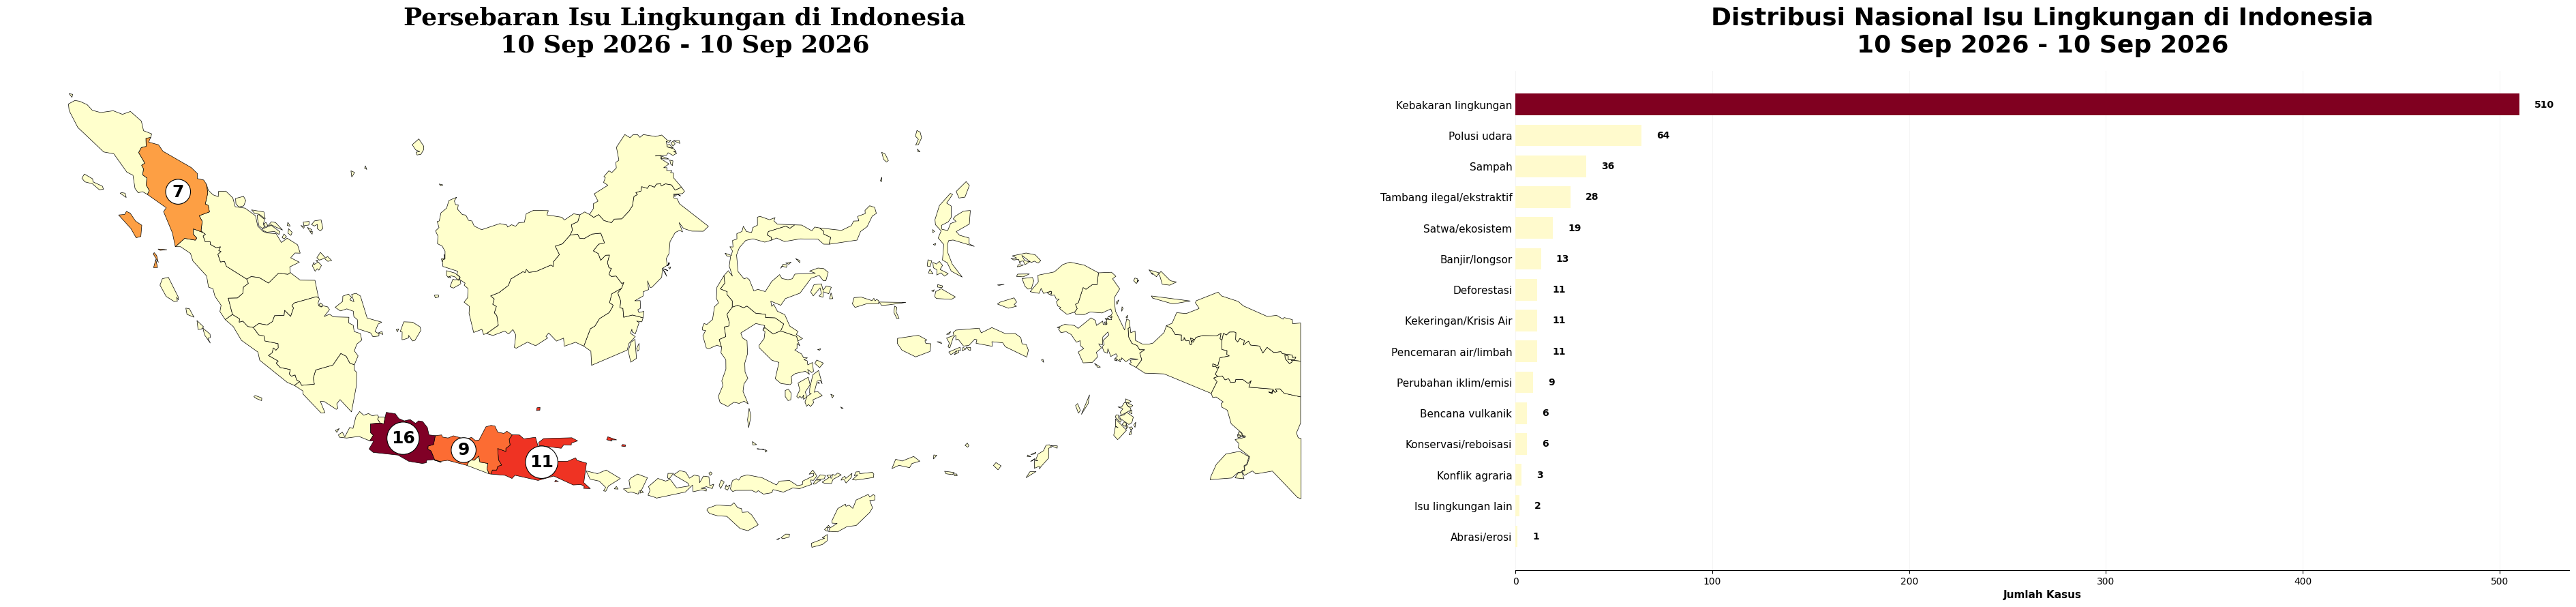

In [35]:
CMAP_NAME = "YlOrRd"
TITLE_SIZE = 26

GEOJSON_PATH = "indonesia_38_provinsi.geojson"
GEOJSON_URL = (
    "https://raw.githubusercontent.com/denyherianto/"
    "indonesia-geojson-topojson-maps-with-38-provinces/main/"
    "GeoJSON/indonesia-38-provinces.geojson"
)
EXPECTED_PROVINCE_COUNT = 38

MANUAL_BADGE_POSITION = {
    "KEPULAUAN RIAU": (104.05, 1.30),
    "BALI": (115.15, -8.05),
    "NUSA TENGGARA BARAT": (117.55, -8.20),
}

def _build_ci_map(mapping: dict) -> dict:
    """Versi case-insensitive dari PROVINCE_FIX/GEO_FIX — key & value string
    diseragamkan ke UPPERCASE supaya cocok dengan alur .upper() di script ini."""
    out = {}
    for k, v in mapping.items():
        key = " ".join(str(k).strip().upper().split())
        if isinstance(v, str):
            out[key] = " ".join(v.strip().upper().split())
        else:
            out[key] = v  # np.nan tetap np.nan
    return out

PROVINCE_FIX_CI = _build_ci_map(PROVINCE_FIX)  # untuk kolom "Provinsi" di data
GEO_FIX_CI = _build_ci_map(GEO_FIX)            # untuk kolom nama provinsi di GeoJSON

def _normalize_data_name(name: str) -> str:
    """Normalisasi nama provinsi dari kolom data (survei/scrape)."""
    key = " ".join(str(name).strip().upper().split())
    fixed = PROVINCE_FIX_CI.get(key, key)
    if pd.isna(fixed):
        return "TIDAK DIKETAHUI"
    return fixed

def _normalize_geo_name(name: str) -> str:
    """Normalisasi nama provinsi dari kolom GeoJSON."""
    key = " ".join(str(name).strip().upper().split())
    fixed = GEO_FIX_CI.get(key, key)
    if pd.isna(fixed):
        return "TIDAK DIKETAHUI"
    return fixed

def _detect_province_column(map_gdf: gpd.GeoDataFrame):
    possible_columns = [
        "Provinsi", "Propinsi", "PROVINSI", "PROPINSI",
        "NAME_1", "WADMPR", "provinsi", "name", "NAME",
    ]
    for column in possible_columns:
        if column in map_gdf.columns:
            return column
    return None


def _load_geojson() -> gpd.GeoDataFrame:
    def _download():
        try:
            response = requests.get(GEOJSON_URL, timeout=30)
            response.raise_for_status()
            with open(GEOJSON_PATH, "wb") as file:
                file.write(response.content)
            return True
        except Exception as error:
            print("[ERROR] Gagal download GeoJSON:", error)
            return False

    if not os.path.exists(GEOJSON_PATH):
        if not _download():
            return gpd.GeoDataFrame()

    try:
        map_gdf = gpd.read_file(GEOJSON_PATH)
    except Exception as error:
        print("[ERROR] Gagal membaca GeoJSON:", error)
        return gpd.GeoDataFrame()

    if len(map_gdf) != EXPECTED_PROVINCE_COUNT:
        os.remove(GEOJSON_PATH)
        if not _download():
            return gpd.GeoDataFrame()
        try:
            map_gdf = gpd.read_file(GEOJSON_PATH)
        except Exception as error:
            print("[ERROR] Gagal membaca GeoJSON setelah redownload:", error)
            return gpd.GeoDataFrame()

    return map_gdf


def _get_aggs(data: pd.DataFrame) -> pd.DataFrame:
    if "Provinsi" not in data.columns:
        print("[ERROR] Kolom 'Provinsi' tidak ditemukan pada dataset.")
        return pd.DataFrame(columns=["Provinsi", "jumlah_kasus", "provinsi_normalized"])

    aggs = data.groupby("Provinsi").size().reset_index(name="jumlah_kasus")
    aggs["provinsi_normalized"] = aggs["Provinsi"].apply(_normalize_data_name)
    return aggs


def _get_map_gdf(data: pd.DataFrame) -> gpd.GeoDataFrame:
    map_gdf = _load_geojson()
    if map_gdf.empty:
        print("[ERROR] GeoJSON kosong.")
        return gpd.GeoDataFrame()

    prov_col = _detect_province_column(map_gdf)
    if prov_col is None:
        print("[ERROR] Kolom nama provinsi tidak ditemukan pada GeoJSON.")
        return gpd.GeoDataFrame()

    map_gdf["provinsi_normalized"] = map_gdf[prov_col].apply(_normalize_geo_name)
    aggs = _get_aggs(data)

    map_gdf = map_gdf.merge(
        aggs[["provinsi_normalized", "jumlah_kasus"]],
        on="provinsi_normalized",
        how="left",
    )
    map_gdf["jumlah_kasus"] = map_gdf["jumlah_kasus"].fillna(0)

    return map_gdf


def _main_point(geometry):
    if isinstance(geometry, MultiPolygon):
        largest_polygon = max(geometry.geoms, key=lambda geom: geom.area)
        return largest_polygon.representative_point()
    return geometry.representative_point()


def prepare_data(data: pd.DataFrame):
    data = data.copy()

    data['Date'] = pd.to_datetime(data['Date'], format='ISO8601', errors='coerce').dt.normalize()

    if 'Sentiment' in data.columns:
        data['Sentiment'] = data['Sentiment'].astype(str).str.strip().str.lower()

    data = data.sort_values('Date', ascending=True, na_position='last').reset_index(drop=True)

    valid_dates = data['Date'].dropna()
    if valid_dates.empty:
        start_date = end_date = "Periode tidak diketahui"
    else:
        start_date = valid_dates.iloc[0].strftime('%d %b %Y')
        end_date = valid_dates.iloc[-1].strftime('%d %b %Y')

    return data, start_date, end_date


def plot_combined(data: pd.DataFrame, start_date, end_date):
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(38, 9),
        gridspec_kw={"width_ratios": [1.3, 1]}
    )

    # --- SUBPLOT 1 (KIRI): PETA CHOROPLETH INDONESIA ---
    map_gdf = _get_map_gdf(data)
    if map_gdf.empty:
        print("[WARNING] Peta tidak dapat dirender.")
    else:
        prov_col = _detect_province_column(map_gdf)
        if prov_col is None:
            print("[ERROR] Kolom provinsi tidak ditemukan.")
        else:
            map_gdf.plot(
                column="jumlah_kasus", cmap=CMAP_NAME, linewidth=0.5, edgecolor="black",
                ax=ax1, legend=False,
                missing_kwds={"color": "#ffffe0", "edgecolor": "black", "linewidth": 0.5},
            )

            def _draw_badge(x, y, value):
                ax1.text(
                    x, y, f"{int(value)}", ha="center", va="center", zorder=10,
                    fontsize=18, fontweight="bold", color="black",
                    bbox=dict(boxstyle="circle,pad=0.25", facecolor="white", edgecolor="black", linewidth=0.8),
                )

            for _, row in map_gdf.iterrows():
                value = row["jumlah_kasus"]
                if value <= 0:
                    continue

                province = _normalize_geo_name(row[prov_col])

                if province in MANUAL_BADGE_POSITION:
                    x, y = MANUAL_BADGE_POSITION[province]
                else:
                    point = _main_point(row.geometry)
                    x, y = point.x, point.y

                _draw_badge(x, y, value)

            ax1.set_title(
                f"Persebaran Isu Lingkungan di Indonesia\n{_format_period(start_date, end_date)}",
                fontsize=TITLE_SIZE, fontweight="bold", family="serif", pad=20,
            )
            ax1.axis("off")

    # --- SUBPLOT 2 (KANAN): BAR CHART DISTRIBUSI ISU NASIONAL ---
    if "Isu_Inti" not in data.columns:
        print("[ERROR] Kolom 'Isu_Inti' tidak ditemukan.")
    else:
        counts = data["Isu_Inti"].value_counts().sort_values(ascending=True)
        colors = (["#FFFACD"] * (len(counts) - 1) + ["#800020"]) if len(counts) > 1 else ["#800020"]
        bars = ax2.barh(counts.index, counts.values, color=colors, height=0.7)

        ax2.set_title(
            f"Distribusi Nasional Isu Lingkungan di Indonesia\n{_format_period(start_date, end_date)}",
            fontsize=TITLE_SIZE, fontweight="bold", pad=20,
        )
        ax2.set_xlabel("Jumlah Kasus", fontsize=11, fontweight="bold")
        ax2.tick_params(axis="y", labelsize=11, length=0)
        ax2.spines[["top", "right", "left"]].set_visible(False)
        ax2.xaxis.grid(True, linestyle="-", alpha=0.3, color="#e0e0e0")
        ax2.set_axisbelow(True)

        max_value = counts.max()
        for bar in bars:
            width = bar.get_width()
            ax2.text(
                width + max_value * 0.015, bar.get_y() + bar.get_height() / 2,
                f"{int(width)}", va="center", ha="left", fontsize=10, fontweight="bold",
            )

    plt.tight_layout()
    plt.show()
    return fig


def _format_period(start, end):
    return f"{start} - {end}"


df_clean, start_date, end_date = prepare_data(df_clean)
fig_combined = plot_combined(df_clean, start_date, end_date)

In [36]:
# =========================================================
# KONFIGURASI VISUALISASI
# =========================================================

CMAP_NAME = "YlOrRd"

GEOJSON_PATH = "indonesia_38_provinsi.geojson"
GEOJSON_URL = (
    "https://raw.githubusercontent.com/denyherianto/"
    "indonesia-geojson-topojson-maps-with-38-provinces/main/"
    "GeoJSON/indonesia-38-provinces.geojson"
)
EXPECTED_PROVINCE_COUNT = 38

MANUAL_BADGE_POSITION = {
    "KEPULAUAN RIAU": (104.05, 1.30),
    "BALI": (115.15, -8.05),
    "NUSA TENGGARA BARAT": (117.55, -8.20),
}


# =========================================================
# HELPER: NORMALISASI NAMA PROVINSI (pakai fix dari great)
# =========================================================
def _build_ci_map(mapping: dict) -> dict:
    """Versi case-insensitive dari PROVINCE_FIX/GEO_FIX — key & value string
    diseragamkan ke UPPERCASE supaya cocok dengan alur .upper() di script ini."""
    out = {}
    for k, v in mapping.items():
        key = " ".join(str(k).strip().upper().split())
        if isinstance(v, str):
            out[key] = " ".join(v.strip().upper().split())
        else:
            out[key] = v  # np.nan tetap np.nan
    return out

PROVINCE_FIX_CI = _build_ci_map(PROVINCE_FIX)  # untuk kolom "Provinsi" di data
GEO_FIX_CI = _build_ci_map(GEO_FIX)            # untuk kolom nama provinsi di GeoJSON

# PULAU_MAP dari great keynya Title Case ("Sumatera Utara"), tapi
# _normalize_data_name() di bawah selalu mengembalikan UPPERCASE. Bikin versi
# lookup dengan key UPPERCASE, value (nama pulau) dibiarkan apa adanya karena
# dipakai sebagai label tampilan di bar chart.
PULAU_MAP_CI = {str(k).strip().upper(): v for k, v in PULAU_MAP.items()}

def _normalize_data_name(name: str) -> str:
    """Normalisasi nama provinsi dari kolom data (survei/scrape)."""
    key = " ".join(str(name).strip().upper().split())
    fixed = PROVINCE_FIX_CI.get(key, key)
    if pd.isna(fixed):
        return "TIDAK DIKETAHUI"
    return fixed

def _normalize_geo_name(name: str) -> str:
    """Normalisasi nama provinsi dari kolom GeoJSON."""
    key = " ".join(str(name).strip().upper().split())
    fixed = GEO_FIX_CI.get(key, key)
    if pd.isna(fixed):
        return "TIDAK DIKETAHUI"
    return fixed

def _detect_province_column(map_gdf: gpd.GeoDataFrame):
    possible_columns = [
        "Provinsi", "Propinsi", "PROVINSI", "PROPINSI",
        "NAME_1", "WADMPR", "provinsi", "name", "NAME",
    ]
    for column in possible_columns:
        if column in map_gdf.columns:
            return column
    return None


# =========================================================
# HELPER: PROVINSI -> PULAU (pakai PULAU_MAP dari great)
# =========================================================
def _get_island_aggs(data: pd.DataFrame) -> pd.Series:
    provinces = data["Provinsi"].apply(_normalize_data_name)
    islands = provinces.map(PULAU_MAP_CI)
    return islands.value_counts().sort_values(ascending=True)


# =========================================================
# HELPER: DOWNLOAD / LOAD GEOJSON
# =========================================================
def _load_geojson() -> gpd.GeoDataFrame:
    def _download():
        try:
            response = requests.get(GEOJSON_URL, timeout=30)
            response.raise_for_status()
            with open(GEOJSON_PATH, "wb") as file:
                file.write(response.content)
            return True
        except Exception as error:
            print("[ERROR] Gagal download GeoJSON:", error)
            return False

    if not os.path.exists(GEOJSON_PATH):
        if not _download():
            return gpd.GeoDataFrame()

    try:
        map_gdf = gpd.read_file(GEOJSON_PATH)
    except Exception as error:
        print("[ERROR] Gagal membaca GeoJSON:", error)
        return gpd.GeoDataFrame()

    if len(map_gdf) != EXPECTED_PROVINCE_COUNT:
        os.remove(GEOJSON_PATH)
        if not _download():
            return gpd.GeoDataFrame()
        try:
            map_gdf = gpd.read_file(GEOJSON_PATH)
        except Exception as error:
            print("[ERROR] Gagal membaca GeoJSON setelah redownload:", error)
            return gpd.GeoDataFrame()

    return map_gdf


# =========================================================
# HELPER: AGREGASI JUMLAH KASUS
# =========================================================
def _get_aggs(data: pd.DataFrame) -> pd.DataFrame:
    if "Provinsi" not in data.columns:
        print("[ERROR] Kolom 'Provinsi' tidak ditemukan pada dataset.")
        return pd.DataFrame(columns=["Provinsi", "jumlah_kasus", "provinsi_normalized"])

    aggs = data.groupby("Provinsi").size().reset_index(name="jumlah_kasus")
    aggs["provinsi_normalized"] = aggs["Provinsi"].apply(_normalize_data_name)
    return aggs


# =========================================================
# HELPER: MENYIAPKAN GEODATAFRAME (peta + jumlah kasus)
# =========================================================
def _get_map_gdf(data: pd.DataFrame) -> gpd.GeoDataFrame:
    map_gdf = _load_geojson()
    if map_gdf.empty:
        print("[ERROR] GeoJSON kosong.")
        return gpd.GeoDataFrame()

    prov_col = _detect_province_column(map_gdf)
    if prov_col is None:
        print("[ERROR] Kolom nama provinsi tidak ditemukan pada GeoJSON.")
        return gpd.GeoDataFrame()

    map_gdf["provinsi_normalized"] = map_gdf[prov_col].apply(_normalize_geo_name)
    aggs = _get_aggs(data)

    map_gdf = map_gdf.merge(
        aggs[["provinsi_normalized", "jumlah_kasus"]],
        on="provinsi_normalized",
        how="left",
    )
    map_gdf["jumlah_kasus"] = map_gdf["jumlah_kasus"].fillna(0)

    return map_gdf


# =========================================================
# HELPER: TITIK UTAMA PROVINSI
# =========================================================
def _main_point(geometry):
    if isinstance(geometry, MultiPolygon):
        largest_polygon = max(geometry.geoms, key=lambda geom: geom.area)
        return largest_polygon.representative_point()
    return geometry.representative_point()


# =========================================================
# VISUAL GABUNGAN: HEADER + PETA (COLORBAR) + 2 BAR CHART
# =========================================================
def plot_dashboard(data: pd.DataFrame, start_date, end_date, report_date: str = None):
    fig = plt.figure(figsize=(30, 14))
    gs = fig.add_gridspec(2, 2, width_ratios=[3.2, 1], height_ratios=[1, 1], hspace=0.35, wspace=0.1)

    ax_map = fig.add_subplot(gs[:, 0])
    ax_nasional = fig.add_subplot(gs[0, 1])
    ax_pulau = fig.add_subplot(gs[1, 1])

    # --- PETA (dengan colorbar, badge proporsional) ---
    map_gdf = _get_map_gdf(data)
    if map_gdf.empty:
        print("[WARNING] Peta tidak dapat dirender.")
    else:
        prov_col = _detect_province_column(map_gdf)

        map_gdf.plot(
            column="jumlah_kasus", cmap=CMAP_NAME, linewidth=0.5, edgecolor="black",
            ax=ax_map, legend=True,
            legend_kwds={"label": "Jumlah kasus/isu", "shrink": 0.55, "pad": 0.02},
            missing_kwds={"color": "#d9d9d9", "edgecolor": "black", "linewidth": 0.5},
        )

        minx, miny, maxx, maxy = map_gdf.total_bounds
        pad_x, pad_y = (maxx - minx) * 0.03, (maxy - miny) * 0.05
        ax_map.set_xlim(minx - pad_x, maxx + pad_x)
        ax_map.set_ylim(miny - pad_y, maxy + pad_y)
        ax_map.set_aspect("equal")

        max_value = map_gdf["jumlah_kasus"].max() or 1

        for _, row in map_gdf.iterrows():
            value = row["jumlah_kasus"]
            if value <= 0:
                continue

            province = _normalize_geo_name(row[prov_col])
            if province in MANUAL_BADGE_POSITION:
                x, y = MANUAL_BADGE_POSITION[province]
            else:
                point = _main_point(row.geometry)
                x, y = point.x, point.y

            scale = (value / max_value) ** 0.5
            font_size = 18 + scale * 5

            ax_map.text(
                x, y, f"{int(value)}", ha="center", va="center", zorder=10,
                fontsize=font_size, fontweight="bold", color="black",
                bbox=dict(boxstyle="circle,pad=0.3", facecolor="white",
                          edgecolor="black", linewidth=0.6),
            )

        ax_map.set_title("Persebaran Isu Lingkungan di Indonesia", fontsize=20, fontweight="bold", pad=14)
        ax_map.axis("off")

    # --- BAR CHART NASIONAL ---
    if "Isu_Inti" in data.columns:
        counts = data["Isu_Inti"].value_counts().sort_values(ascending=True)
        colors = plt.colormaps[CMAP_NAME]([v / counts.max() for v in counts.values])
        bars = ax_nasional.barh(counts.index, counts.values, color=colors, height=0.65)
        ax_nasional.set_title("Distribusi Nasional Isu Lingkungan di Indonesia", fontsize=20, fontweight="bold", pad=12)
        ax_nasional.set_xlabel("Jumlah kasus", fontsize=14)
        ax_nasional.tick_params(labelsize=14, length=0)
        ax_nasional.spines[["top", "right", "left"]].set_visible(False)
        ax_nasional.xaxis.grid(True, alpha=0.3)
        ax_nasional.set_axisbelow(True)
        max_value_n = counts.max()
        for bar in bars:
            width = bar.get_width()
            ax_nasional.text(width + max_value_n * 0.015, bar.get_y() + bar.get_height() / 2,
                              f"{int(width)}", va="center", fontsize=18, fontweight="bold")

    # --- BAR CHART PER PULAU ---
    if "Provinsi" in data.columns:
        island_counts = _get_island_aggs(data)
        colors_pulau = plt.colormaps[CMAP_NAME]([v / island_counts.max() for v in island_counts.values])
        bars2 = ax_pulau.barh(island_counts.index, island_counts.values, color=colors_pulau, height=0.65)
        ax_pulau.set_title("Distribusi Kasus Isu Lingkungan per Pulau", fontsize=20, fontweight="bold", pad=12)
        ax_pulau.set_xlabel("Jumlah kasus", fontsize=14)
        ax_pulau.tick_params(labelsize=14, length=0)
        ax_pulau.spines[["top", "right", "left"]].set_visible(False)
        ax_pulau.xaxis.grid(True, alpha=0.3)
        ax_pulau.set_axisbelow(True)
        max_value2 = island_counts.max()
        for bar in bars2:
            width = bar.get_width()
            ax_pulau.text(width + max_value2 * 0.015, bar.get_y() + bar.get_height() / 2,
                           f"{int(width)}", va="center", fontsize=18, fontweight="bold")


    plt.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.05)
    plt.show()
    return fig

df_clean, start_date, end_date = prepare_data(df_clean)

In [37]:
df_berita = df_clean[df_clean["Tipe_Link"] == "Berita"]

top5_pulau = (
    df_berita[~df_berita["Pulau"].isin(["Tidak Terdeteksi"])]
    .groupby("Pulau").size().sort_values(ascending=False).head(5).index.tolist()
)

berita_rows = []
for pulau in top5_pulau:
    subset = df_berita[df_berita["Pulau"] == pulau]
    top2_isu = subset["Isu_Inti"].value_counts().head(2)
    for isu, jumlah_isu in top2_isu.items():
        links = subset[subset["Isu_Inti"] == isu]["Link"].head(5).tolist()
        for link in links:
            berita_rows.append({"Pulau": pulau, "Isu": isu, "Jumlah Berita (Isu)": jumlah_isu, "Link": link})

berita_table = pd.DataFrame(berita_rows)
print("BERITA — 5 PULAU TERATAS, 2 ISU TERAMAI PER PULAU:")
display(berita_table)

df_medsos = df_clean[df_clean["Tipe_Link"] == "Media Sosial"]
top5_isu_medsos = df_medsos["Isu_Inti"].value_counts().head(5)

medsos_rows = []
for isu, jumlah_isu in top5_isu_medsos.items():
    links = df_medsos[df_medsos["Isu_Inti"] == isu]["Link"].head(5).tolist()
    for link in links:
        medsos_rows.append({"Isu": isu, "Jumlah Postingan (Isu)": jumlah_isu, "Link": link})

medsos_table = pd.DataFrame(medsos_rows)
print("\nMEDIA SOSIAL — 5 ISU TERAMAI:")
display(medsos_table)

BERITA — 5 PULAU TERATAS, 2 ISU TERAMAI PER PULAU:


,Pulau,Isu,Jumlah Berita (Isu),Link
0,Jawa,Kebakaran lingkungan,17,https://binews.id/berita/26337/sejumlah-daerah...
1,Jawa,Kebakaran lingkungan,17,https://koranbernas.id/terjadi-lagi-kebakaran-...
2,Jawa,Kebakaran lingkungan,17,https://suarabanyuurip.com/2026/09/10/pertamin...
3,Jawa,Kebakaran lingkungan,17,https://www.ayosemarang.com/umum/7717616879/an...
4,Jawa,Kebakaran lingkungan,17,https://kumparan.com/kumparannews/kisah-para-p...
5,Jawa,Sampah,6,https://news.detik.com/berita/d-8656847/pramon...
6,Jawa,Sampah,6,https://radarsukabumi.com/kabupaten-sukabumi/p...
7,Jawa,Sampah,6,https://republiknews.com/wabup-mimik-idayana-p...
8,Jawa,Sampah,6,https://www.cnbcindonesia.com/news/20260910080...
9,Jawa,Sampah,6,https://jatimsatunews.com/2026/09/wabup-mimik-...



MEDIA SOSIAL — 5 ISU TERAMAI:


,Isu,Jumlah Postingan (Isu),Link
0,Kebakaran lingkungan,169,https://www.instagram.com/p/DdGKqwgv5qS
1,Kebakaran lingkungan,169,https://www.tiktok.com/@ren_resmuna/photo/7683...
2,Kebakaran lingkungan,169,https://www.instagram.com/p/DdGFRW2EfZJ
3,Kebakaran lingkungan,169,https://www.youtube.com/watch?v=_l66AE3bxDo
4,Kebakaran lingkungan,169,https://twitter.com/web/statuses/2097912199042...
5,Polusi udara,17,https://www.youtube.com/watch?v=CGqak98-oAw
6,Polusi udara,17,https://twitter.com/web/statuses/2097885131193...
7,Polusi udara,17,https://www.tiktok.com/@setwapres.ri/video/768...
8,Polusi udara,17,https://twitter.com/web/statuses/2097866934142...
9,Polusi udara,17,https://twitter.com/web/statuses/2097864957753...


# UNTUK PERKAYA SOURCE

In [38]:
STOPWORDS_ID = set("""
yang di ke dari dan atau untuk pada dengan dalam ini itu adalah akan telah
sudah tidak juga karena oleh sebagai atas dapat bisa saat ketika para
antara namun tetapi jika kata ada tahun hari lalu kemarin sebut ujar
kata dia mereka kami kita saya anda tersebut baik serta hingga sekitar
lebih dua satu tiga bagi setelah sejak selama menjadi terkait
""".split())

def top_terms(texts, n=40, ngram=1):
    counter = Counter()
    for t in texts:
        words = re.findall(r'\b[a-z]{3,}\b', str(t).lower())
        words = [w for w in words if w not in STOPWORDS_ID]
        if ngram == 1:
            counter.update(words)
        else:
            grams = zip(*[words[i:] for i in range(ngram)])
            counter.update(" ".join(g) for g in grams)
    return counter.most_common(n)

def report_uncovered(df, column, label, n_sample=20):
    subset = df.loc[df[column] == label, "search_text"]
    print(f"Jumlah dokumen '{label}': {len(subset)}\n")
    print("Top kata:")
    for w, c in top_terms(subset, n=40, ngram=1):
        print(f"  {w}: {c}")
    print("\nTop frasa 2 kata:")
    for p, c in top_terms(subset, n=30, ngram=2):
        print(f"  {p}: {c}")
    display(df.loc[df[column] == label, ["doc_id", "Mentions"]].sample(min(n_sample, len(subset)), random_state=42))

report_uncovered(df_clean, "Isu_Inti", "Isu Lingkungan Lainnya")
print("\n" + "=" * 60 + "\n")
report_uncovered(df_clean, "Provinsi", "Tidak Terdeteksi")

Jumlah dokumen 'Isu Lingkungan Lainnya': 0

Top kata:

Top frasa 2 kata:


,doc_id,Mentions




Jumlah dokumen 'Tidak Terdeteksi': 0

Top kata:

Top frasa 2 kata:


,doc_id,Mentions
